# Notebook - Find best Drug compound for different bacteria
- Bacillus subtilis
- Bacillus cereus
- Staphylococcus aureus
- Enterococcus faecalis
- Listeria monocytogenes

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import csv
import numpy as np
import pandas as pd


from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [3]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [5]:
allBacteriaData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM_wMACAW.csv')

In [6]:
allBacteriaData_chEMBL_wMACAW.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'smiles', 'molecular_formula',
       'inchi_key', 'inchi', 'molecular_weight', 'type', 'standard_value',
       'standard_units', 'standard_relation', 'standard_type', 'pchembl_value',
       'AlogP', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds',
       'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Virus',
       'value_uM', 'pPotency', 'is_convertible_to_uM', 'potency_family',
       'pPotencyMid', 'invalidSmiles', 'macaw_0', 'macaw_1', 'macaw_2',
       'macaw_3', 'macaw_4', 'macaw_5', 'macaw_6', 'macaw_7', 'macaw_8',
       'macaw_9', 'macaw_10', 'macaw_11', 'macaw_12', 'macaw_13', 'macaw_14'],
      dtype='object')

### Filter columns

In [7]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenesData_chEMBL_combined.csv
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenesData_chEMBL_combined.csv
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenesData_chEMBL_combined.csv
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenesData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [8]:
allBacteriaData_chEMBL_wMACAW['Virus'] = allBacteriaData_chEMBL_wMACAW['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL_wMACAW.rename(columns={'Virus': 'Bacteria'}, inplace=True)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenes
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenes
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenes
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenes


### Add some randomization

### Rename columns

In [9]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Bacteria" : "BacteriaClassifier",
})
allBacteriaData_chEMBL_wMACAW.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.25,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.00,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.50,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.00,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.00,Bacillus_subtilis


### Compound Distribution Across Bacteriaes

In [10]:
Bacteria_counts = allBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(allBacteriaData_chEMBL_wMACAW)

print(f"\n{'Bacteria':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for Bacteria, count in Bacteria_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{Bacteria:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique Bacteriaes: {len(Bacteria_counts)}")


Bacteria                            Count   Percentage
----------------------------------------------------------------------
Staphylococcus_aureus              123802       76.24%
Enterococcus_faecalis               18742       11.54%
Bacillus_subtilis                   15371        9.47%
Bacillus_cereus                      3402        2.10%
Listeria_monocytogenes               1061        0.65%
----------------------------------------------------------------------
TOTAL                              162378      100.00%

Number of unique Bacteriaes: 5


### Add `ID` column to left

In [11]:
allBacteriaData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(allBacteriaData_chEMBL_wMACAW) + 1))
allBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.25,Bacillus_subtilis
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.00,Bacillus_subtilis
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.50,Bacillus_subtilis
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.00,Bacillus_subtilis
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.00,Bacillus_subtilis


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [12]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
allBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,0.25,Bacillus_subtilis
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,100.00,Bacillus_subtilis
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,1.50,Bacillus_subtilis
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,16.00,Bacillus_subtilis
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,16.00,Bacillus_subtilis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [13]:
print("Original shape:", allBacteriaData_chEMBL_wMACAW.shape)

allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW[allBacteriaData_chEMBL_wMACAW['pPotency'].notna() 
    & (allBacteriaData_chEMBL_wMACAW['pPotency'] > 0) & (allBacteriaData_chEMBL_wMACAW['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", allBacteriaData_chEMBL_wMACAW.shape)

Original shape: (162378, 5)
Shape after cleaning 'pPotency' value: (115562, 5)


### Remove duplicate compounds using Compute median potency per (Smiles, Bacteria) pair

In [14]:
duplicates = allBacteriaData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'BacteriaClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 63789


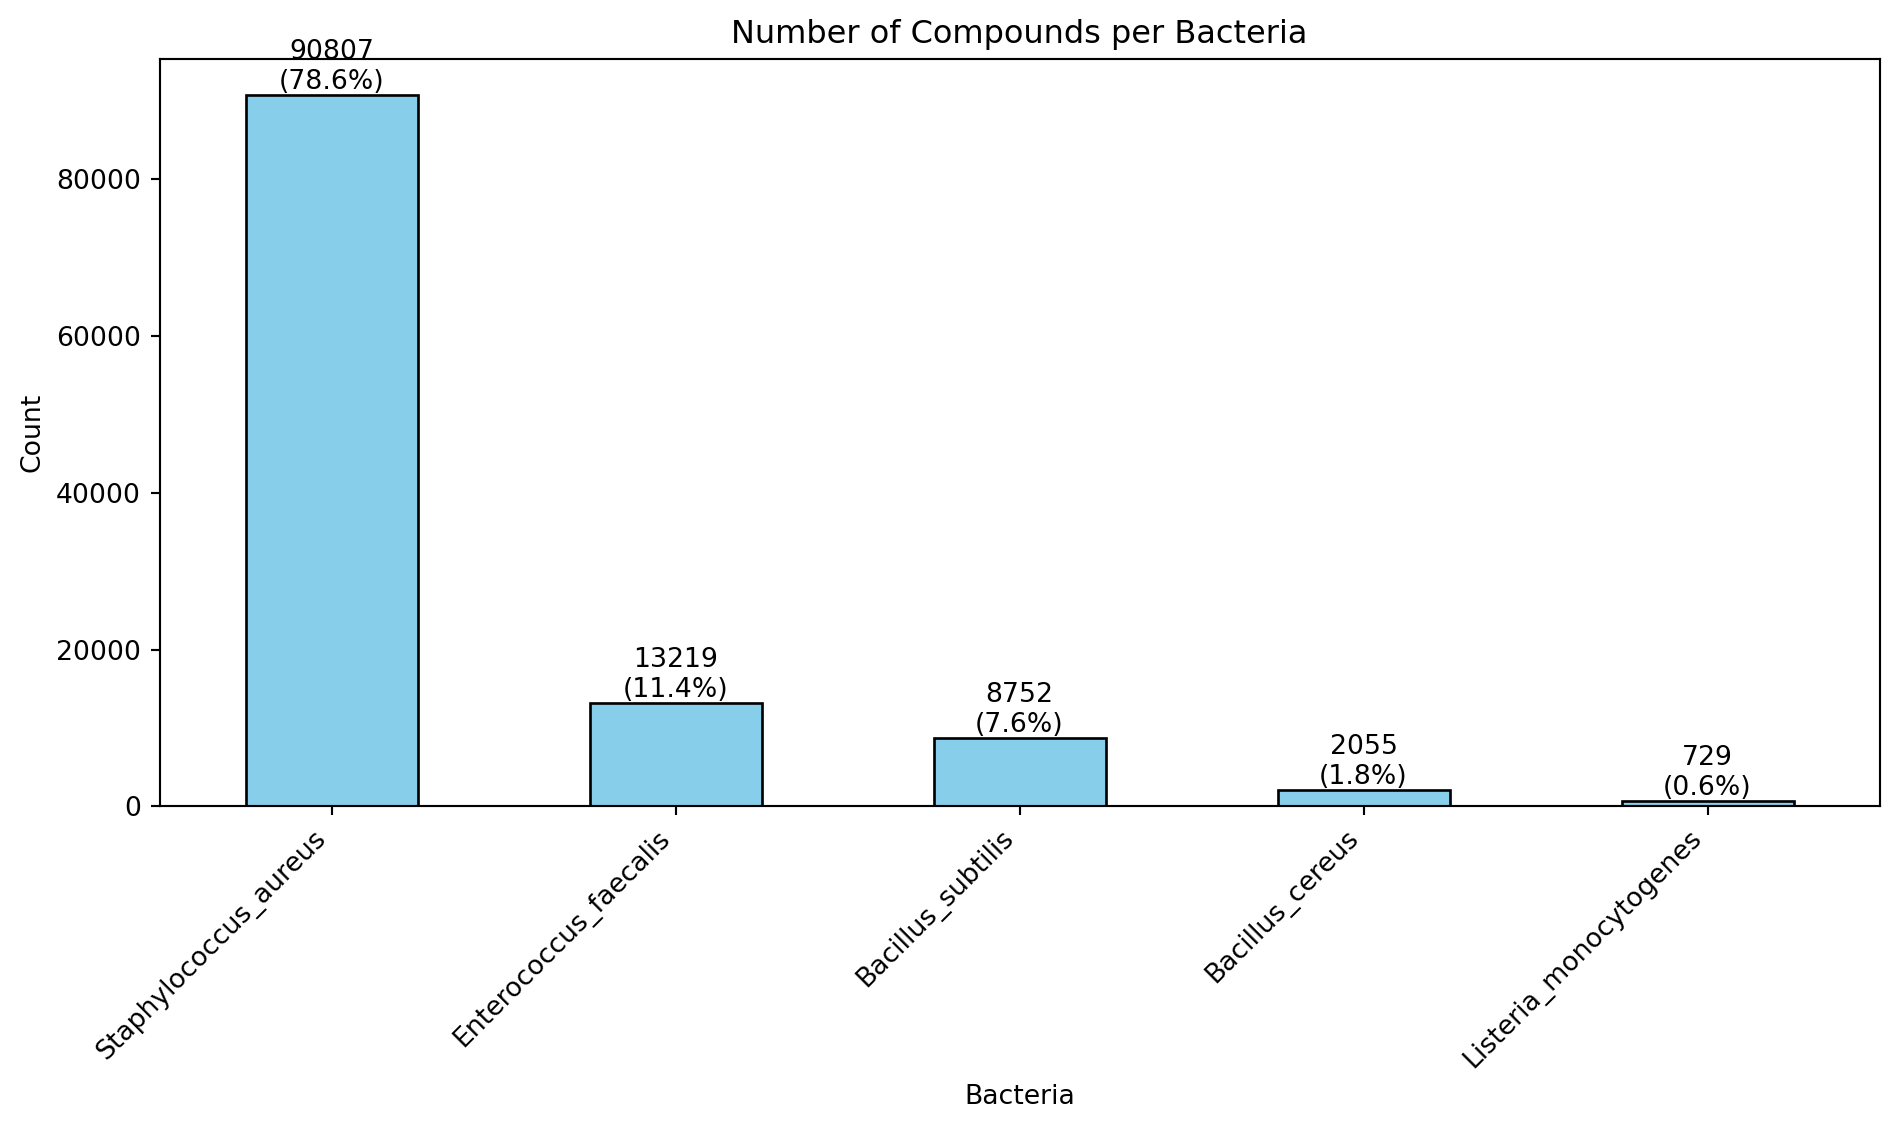

In [15]:
# Get counts and percentages
counts = allBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [16]:
allBacteriaData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "allBacteriaData_chEMBL_wMACAW_MLready.csv"), index=False)

### Arrange bacteria alphabetically

In [17]:
allBacteriaData_chEMBL_wMACAW_ordered = allBacteriaData_chEMBL_wMACAW.sort_values(by='BacteriaClassifier')
allBacteriaData_chEMBL_wMACAW_ordered.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
15626,15627,CHEMBL2238138,CCOC(=O)C1=C(C)N=C2Sc3ccccc3N2C1c1ccc([N+](=O)...,6.25,Bacillus_cereus
16582,16583,CHEMBL5315124,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,0.15,Bacillus_cereus
16583,16584,CHEMBL1782133,C=C1CC[C@H]2C(C)(C)C(=O)CC[C@]2(C)[C@H]1CCC1=C...,3.12,Bacillus_cereus
16585,16586,CHEMBL3754521,COc1c(OCCCCN(C)C)cc2oc3cc(OCCCCN(C)C)c(CC=C(C)...,6.25,Bacillus_cereus
16587,16588,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,6.25,Bacillus_cereus


### pPotency value distribution across each bacteria

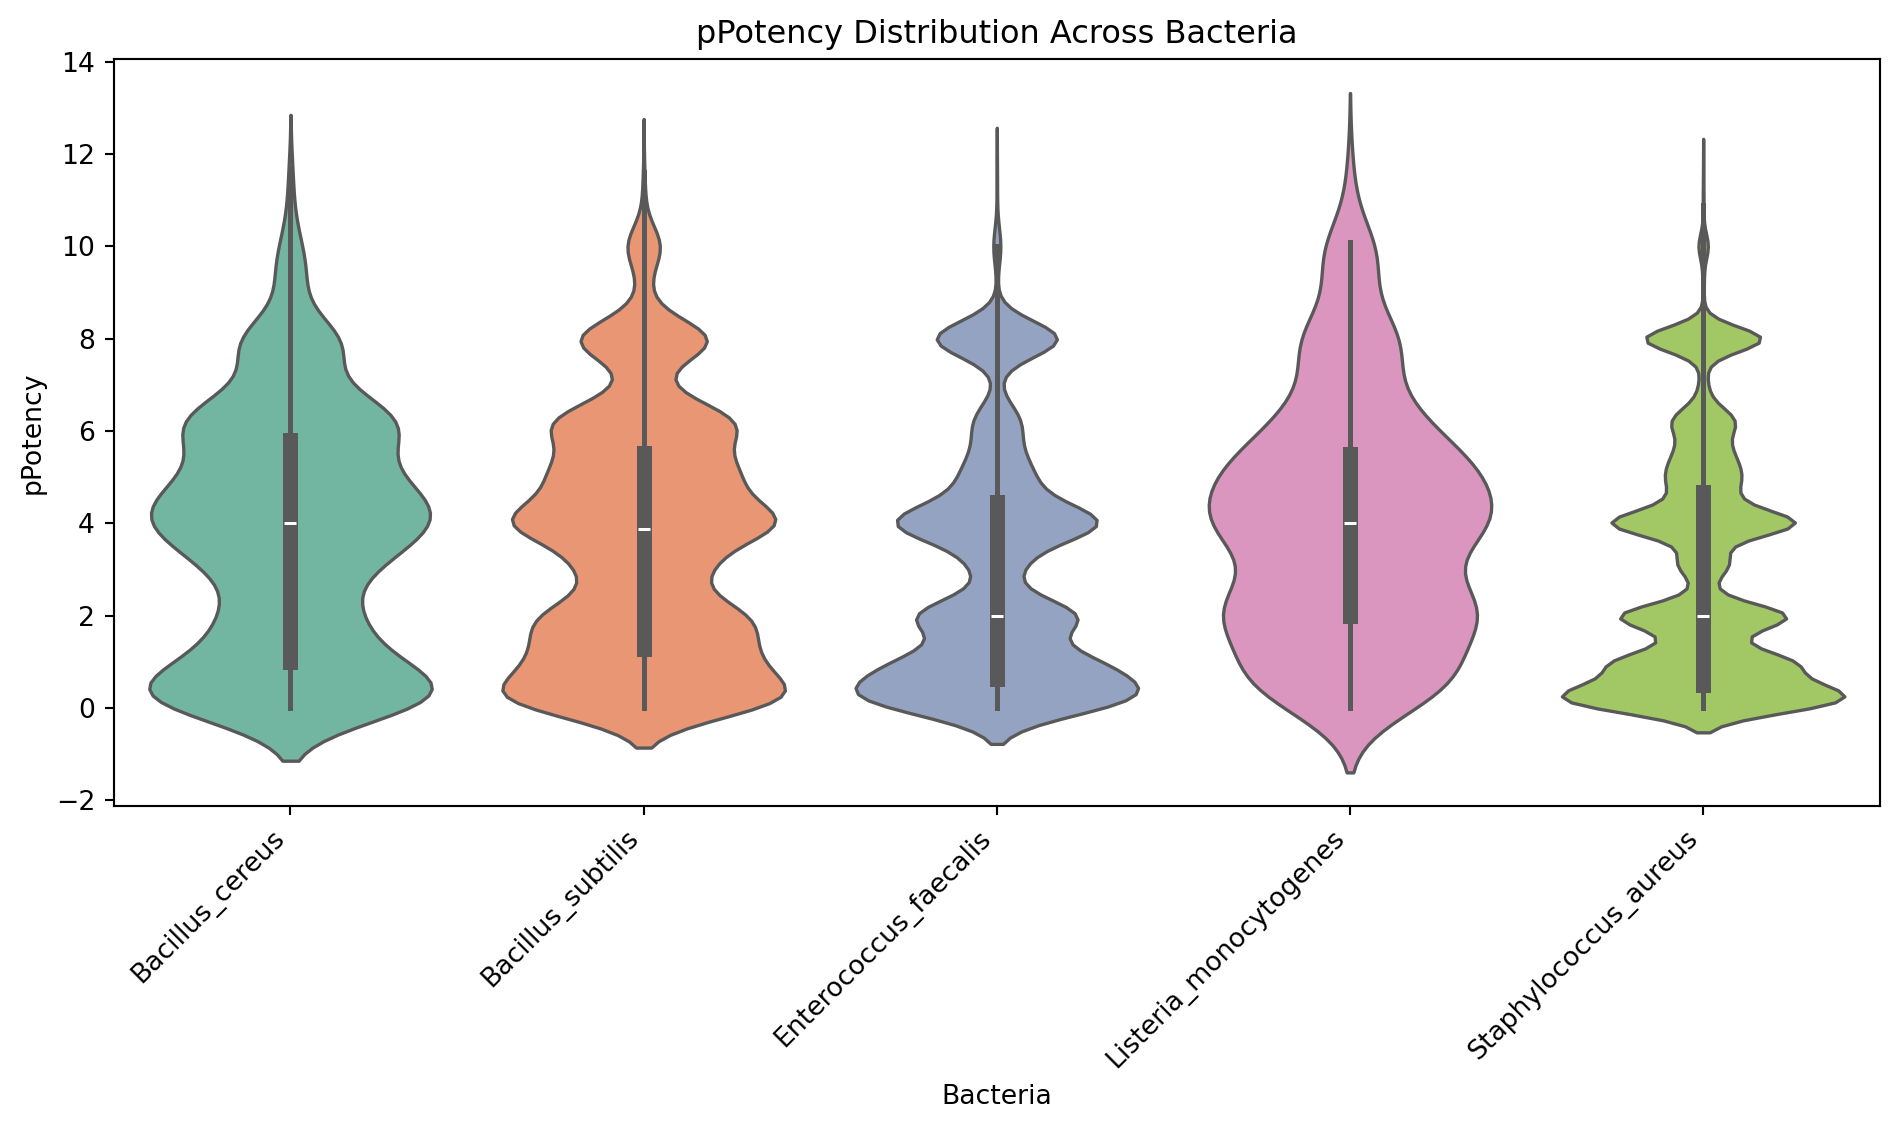

In [18]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=allBacteriaData_chEMBL_wMACAW_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

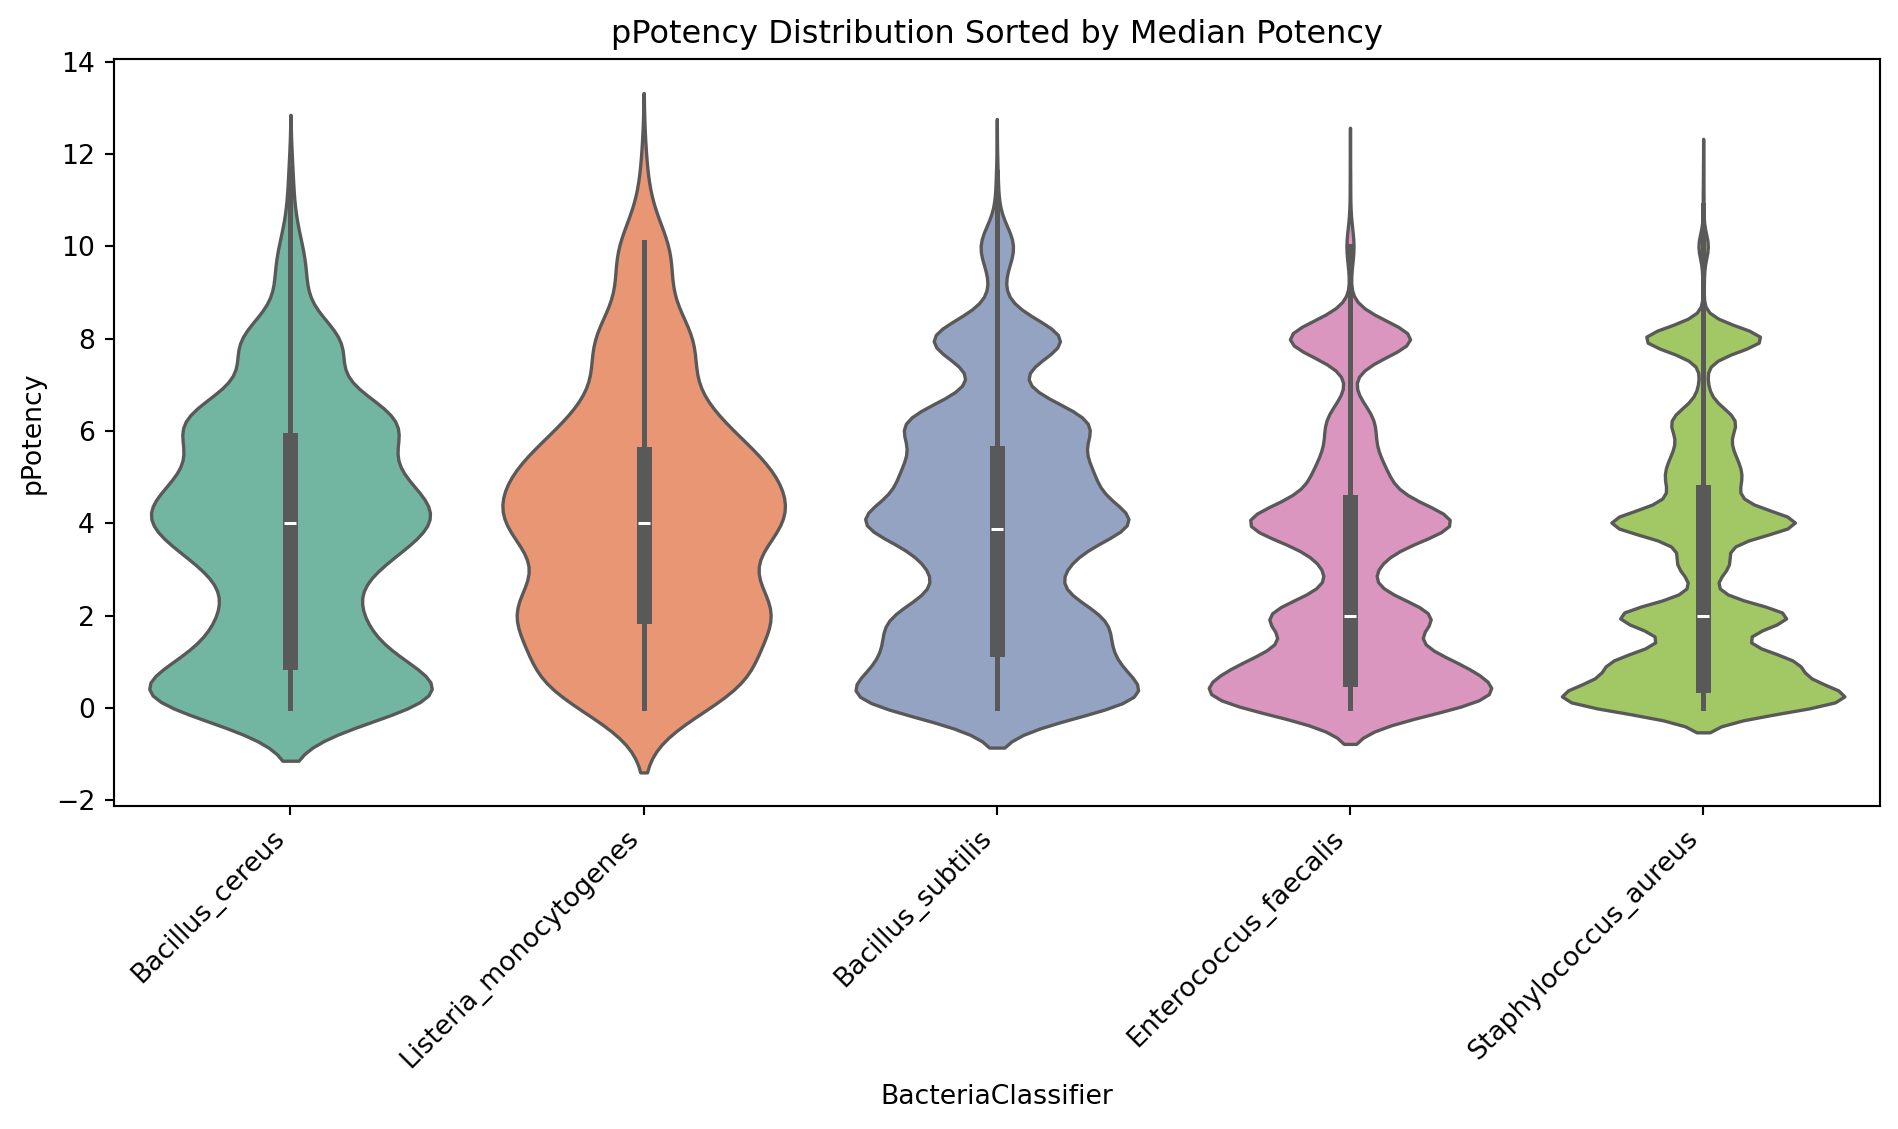

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=allBacteriaData_chEMBL_wMACAW_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    order=(
        allBacteriaData_chEMBL_wMACAW_ordered
        .groupby('BacteriaClassifier')['pPotency']
        .median()
        .sort_values(ascending=False)
        .index
    )
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Sorted by Median Potency')
plt.tight_layout()
plt.show()

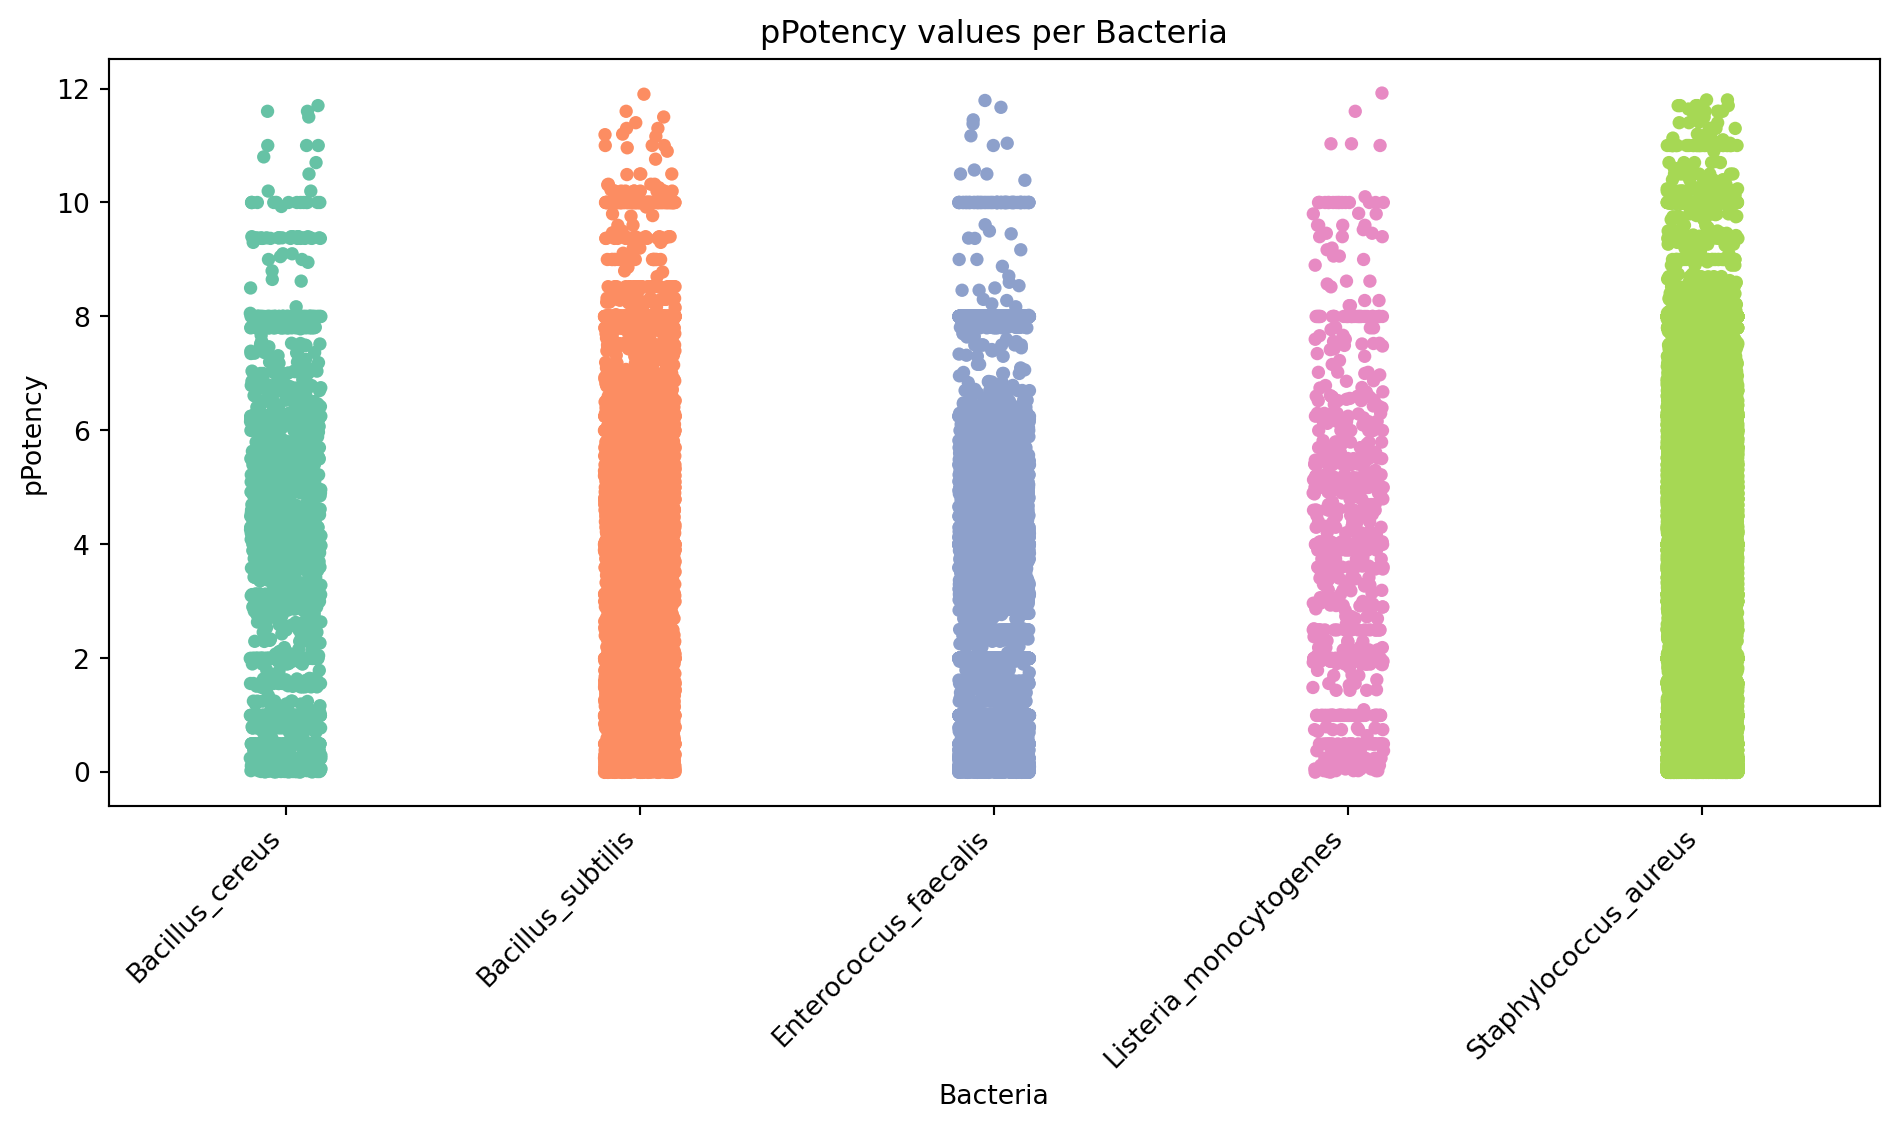

In [20]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=allBacteriaData_chEMBL_wMACAW_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [21]:
# df = allBacteriaData_chEMBL_wMACAW
Y = allBacteriaData_chEMBL_wMACAW.pPotency
smiles = allBacteriaData_chEMBL_wMACAW.Smiles

In [22]:
print(len(smiles))

115562


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

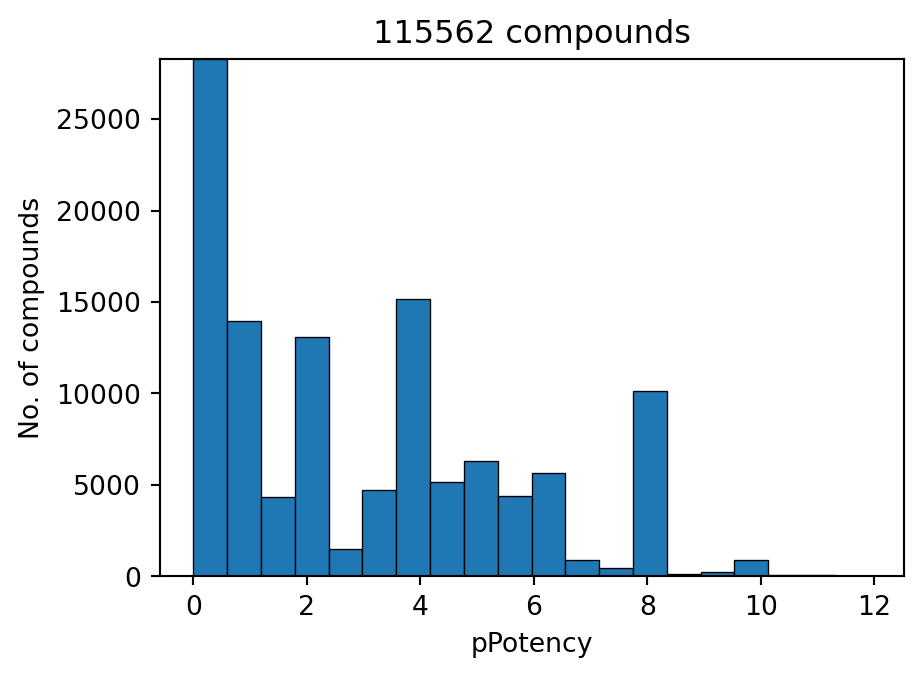

In [23]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [24]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [25]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [26]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [27]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 115562 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Test only results

### ML predictions with Train + Test results

In [28]:
commandLineData_train = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/predictions_train_SVR.csv')
Y_obs_train = commandLineData_train['Observed'].values
Y_cv_pred_train = commandLineData_train['Predicted'].values

In [29]:
commandLineData_test = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/predictions_test_SVR.csv')
Y_obs_test = commandLineData_test['Observed'].values
Y_cv_pred_test = commandLineData_test['Predicted'].values

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_CV_TrTs.png


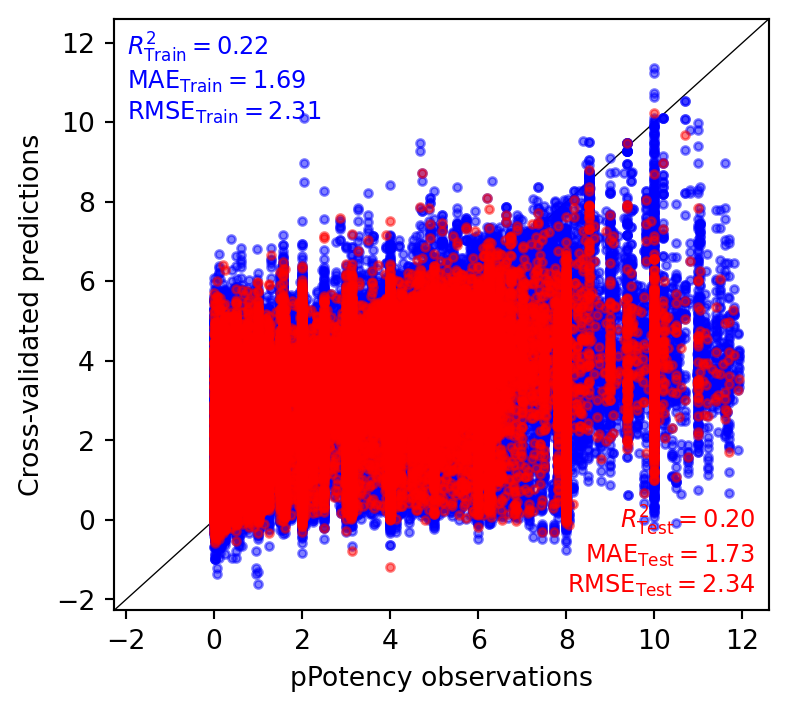

In [30]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [34]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [35]:
X_all = mcw.transform(smiles)
X_all.shape

50000
100000


(115562, 15)

In [ ]:
# Optimize hyperparameters
regr_pred = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
regr_pred.fit(X_all, Y)
print(regr_pred.best_params_)

# Train set predictions
y_pred = regr_pred.predict(X_all)
print(f"R^2 = {r2_score(y_pred, Y):0.2f}")

## 2. Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [36]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(EnamineAntibacterialsData.shape)
smi_lib = EnamineAntibacterialsData.SMILES
EnamineAntibacterialsData.head()

(32000, 11)


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.60,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.50,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.01,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.70,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.70,4,https://real.enamine.net/public-enum-files/Z15...


Generate predictions for the H1 receptor:

In [37]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

NameError: name 'regr_pred' is not defined

Let us represent the predictions of both models:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

# Build feature matrix X and targets (regression + classification)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVC
from sklearn.metrics import f1_score, balanced_accuracy_score
from copy import deepcopy

In [ ]:
yReg = allBacteriaData_chEMBL_wMACAW["pPotency"].to_numpy(dtype=np.float32)

labelEncoder = LabelEncoder()
yCls = labelEncoder.fit_transform(allBacteriaData_chEMBL_wMACAW["BacteriaClassifier"].astype(str).to_numpy())
BacteriaClasses = labelEncoder.classes_
print(f"[Info] Bacteria classes: {len(BacteriaClasses)}")

Train/valid split

In [ ]:
XTrain, XValid, yRegTrain, yRegValid, yClsTrain, yClsValid = train_test_split(
    XAll, yReg, yCls, test_size=0.2, random_state=42, stratify=yCls
)

Define the partitions for cross-validation.

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [ ]:
param_grid_reg = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)

Regression

In [ ]:
smiles = allBacteriaData_chEMBL_wMACAW["Smiles"].astype(str).reset_index(drop=True)
Y = allBacteriaData_chEMBL_wMACAW["pPotency"].to_numpy(dtype=np.float32)

# Ensure smiles is a pandas Series
if isinstance(smiles, np.ndarray):
    smiles = pd.Series(smiles)
if isinstance(Y, np.ndarray):
    Y = pd.Series(Y)

# Drop NaN or missing targets
validMaskY = Y.notna() & ~Y.isnull()
smiles = smiles[validMaskY].reset_index(drop=True)
Y = Y[validMaskY].reset_index(drop=True)

# Validate SMILES strings
validIdx = []
for i, s in enumerate(smiles):
    if isinstance(s, str) and len(s) > 0 and Chem.MolFromSmiles(s) is not None:
        validIdx.append(i)

smiles = smiles.iloc[validIdx].reset_index(drop=True)
Y = Y.iloc[validIdx].reset_index(drop=True)

print(f" Cleaned data has: {len(smiles)} valid samples after dropping NaN targets and invalid SMILES.")
print(f"Example indices: {Y.index[:10].tolist()}")

In [ ]:
YcvPred = []
Yobs = []
bestParamsPerFold = []

foldId = 1
for trainIndex, valIndex in kf.split(smiles):
    print(f"Partition {foldId}/{kf.get_n_splits()}")
    foldId += 1

    smiTrain, smiVal = smiles.iloc[trainIndex], smiles.iloc[valIndex]
    yTrain, yVal = Y[trainIndex], Y[valIndex]

    # --- fit MACAW on TRAIN only (clone to avoid contaminating global mcw) ---
    mcwFold = deepcopy(mcw)
    mcwFold.fit(smiTrain, yTrain)

    XTrain = mcwFold.transform(smiTrain)
    XVal = mcwFold.transform(smiVal)

    # --- inner CV for SVR hyperparams on the TRAIN split ---
    grid = GridSearchCV(
        estimator=SVR(),
        param_grid=param_grid_reg,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        refit=True
    )
    grid.fit(XTrain, yTrain)
    bestParamsPerFold.append(grid.best_params_)

    # --- predict the validation split ---
    yPred = grid.predict(XVal)

    # accumulate
    YcvPred.extend(yPred)
    Yobs.extend(yVal)

### Evaluate cross validation performance

In [ ]:
mae = mean_absolute_error(Yobs, YcvPred)
r2 = r2_score(Yobs, YcvPred)
print(f"[Nested-CV Regression] MAE: {mae:.3f} | R2: {r2:.3f}")
print(f"[Info] Best params per fold (sample): {bestParamsPerFold[:3]}")

In [ ]:
# Parity plot
parity_plot(x=Yobs,
            y=YcvPred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_CV_Reg.svg',
            save_formats=['svg', 'png'])  # Specify both formats

### Generate a model trained on the whole data set, to be used for prediction tasks

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [ ]:
X_all = mcw.transform(smiles)
X_all.shape

In [ ]:
# Fit MACAW on ALL data 
mcwAll = deepcopy(mcw)
mcwAll.fit(smiles, Y)
XAll = mcwAll.transform(smiles)

# Hyperparameter search on ALL data (SVR with 5-fold CV), refit best on ALL
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

regrPred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_reg,  # same grid you defined earlier
    cv=5,
    refit=True,
    n_jobs=-1
)
regrPred.fit(XAll, Y)
print(f"[Refit-All] Best params: {regrPred.best_params_}")

# Train-set predictions and R² on ALL
yPredTrain = regrPred.predict(XAll)
print(f"[Refit-All] R^2 (train) = {r2_score(Y, yPredTrain):.2f}")

In [ ]:
# Parity plot
parity_plot(x=Y,
            y=yPredTrain, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_allData_Reg.svg',
            save_formats=['svg', 'png'])  

# Classification: Cross Validation loop

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

In [ ]:
# For classification we use SVC with RBF; only C is tuned here (gamma='scale' default)
param_grid_cls = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'kernel': ['rbf']
}

### Classification with Morgan (ECFP6) + RandomForest

In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Helpers
# ---------------------------
def morganBits(smilesList, nBits=2048, radius=3):
    """Return (X, validMask) where X is [n_valid, nBits] uint8 array of ECFP bits."""
    fps = []
    validMask = []
    for s in smilesList:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if mol is None:
            validMask.append(False)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.uint8)
        # NOTE: RDKit DataStructs is optional here; ConvertToNumpyArray handles directly if imported.
        # To avoid extra import, we iterate bits:
        onBits = list(fp.GetOnBits())
        arr[onBits] = 1
        fps.append(arr)
        validMask.append(True)
    if len(fps) == 0:
        return np.zeros((0, nBits), dtype=np.uint8), np.array(validMask, dtype=bool)
    return np.vstack(fps), np.array(validMask, dtype=bool)

def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# ---------------------------
# Prepare data
# ---------------------------
DF = allBacteriaData_chEMBL_wMACAW  
assert {"Smiles", "BacteriaClassifier"}.issubset(DF.columns), "Expected Smiles and BacteriaClassifier in DF."

smilesSeries = DF["Smiles"].astype(str).reset_index(drop=True)
labelsStr = DF["BacteriaClassifier"].astype(str).reset_index(drop=True)

# Encode string labels to ints (for modeling), but we will report strings
labelEncoder = LabelEncoder()
yEncAll = labelEncoder.fit_transform(labelsStr)

# Compute Morgan fingerprints and filter invalids
XAllBits, validMask = morganBits(smilesSeries.tolist(), nBits=2048, radius=3)
yEncAllValid = yEncAll[validMask]
labelsStrValid = labelsStr[validMask].reset_index(drop=True)

if XAllBits.shape[0] < 10:
    raise RuntimeError(f"Too few valid molecules after featurization: {XAllBits.shape[0]}")

print(f"[Info] Valid training molecules: {XAllBits.shape[0]} / {len(smilesSeries)}")

# ---------------------------
# Nested CV (outer stratified K-fold, inner grid search)
# ---------------------------
numOfPartitions = 10
kfOuter = StratifiedKFold(n_splits=numOfPartitions, shuffle=True, random_state=42)

paramGridCls = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # handle imbalance
}

YcvPredCls, YobsCls, bestParamsPerFold = [], [], []
foldId = 1
for trainIndex, valIndex in kfOuter.split(XAllBits, yEncAllValid):
    print(f"Partition {foldId}/{kfOuter.get_n_splits()}")
    foldId += 1

    XTrain, XVal = XAllBits[trainIndex], XAllBits[valIndex]
    yTrainEnc, yValEnc = yEncAllValid[trainIndex], yEncAllValid[valIndex]
    yValStr = labelEncoder.inverse_transform(yValEnc)

    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gridCls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=paramGridCls,
        scoring="f1_macro",
        cv=inner,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gridCls.fit(XTrain, yTrainEnc)
    bestParamsPerFold.append(gridCls.best_params_)

    yPredEnc = gridCls.predict(XVal)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)

    YcvPredCls.extend(yPredStr.tolist())
    YobsCls.extend(yValStr.tolist())

### Cross Validation metrics

In [ ]:
f1Cv  = f1_score(YobsCls, YcvPredCls, average="macro")
baCv  = balanced_accuracy_score(YobsCls, YcvPredCls)
accCv = accuracy_score(YobsCls, YcvPredCls)
print(f"[Nested-CV] Classification | F1-macro: {f1Cv:.3f} | Balanced Acc: {baCv:.3f} | Acc: {accCv:.3f}")
print(f"[Info] Best params (sample): {bestParamsPerFold[:3]}")

### Cross Validation Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yTrue = YobsCls   # true labels (strings)
yPred = YcvPredCls  # predicted labels (strings)

cm = confusion_matrix(yTrue, yPred, labels=np.unique(yTrue), normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yTrue))
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='.2f')
plt.title("Confusion Matrix (Validation Predictions)")
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Cross Validation Per-class precision/recall/F1 values

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(yTrue, yPred, output_dict=True)
reportDF = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows
reportDF[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,4))
plt.title("Per-Class Precision/Recall/F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Refit on ALL valid data

In [ ]:
finalGrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=paramGridCls,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
    verbose=0
)
finalGrid.fit(XAllBits, yEncAllValid)
finalCls = finalGrid.best_estimator_
print(f"[Refit-All] Best params: {finalGrid.best_params_}")

### In-sample metrics on ALL valid

In [ ]:
yAllPredEnc = finalCls.predict(XAllBits)
yAllPredStr = labelEncoder.inverse_transform(yAllPredEnc)
print(f"[Refit-All] F1-macro (train): {f1_score(labelsStrValid, yAllPredStr, average='macro'):.3f}")
print(f"[Refit-All] Balanced Acc (train): {balanced_accuracy_score(labelsStrValid, yAllPredStr):.3f}")
print(f"[Refit-All] Accuracy (train): {accuracy_score(labelsStrValid, yAllPredStr):.3f}")

### Confusion Matrix

In [ ]:
# --- Predictions on ALL (in-sample) ---
yPredEnc = finalCls.predict(XAllBits)

# Class labels (strings) for display
if 'labelEncoder' in globals():
    displayLabels = labelEncoder.classes_
    yTrueStr = labelEncoder.inverse_transform(yEncAllValid)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)
else:
    # fallback: show encoded ints if no encoder is available
    displayLabels = finalCls.classes_
    yTrueStr = yEncAllValid
    yPredStr = yPredEnc


cm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix (Train/All Data)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix (row-normalized by true class)
cm_norm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True, values_format=".2f")
ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Per-class precision/recall/F1 values

In [ ]:
report = classification_report(yTrueStr, yPredStr, target_names=displayLabels, output_dict=True)
rep_df = pd.DataFrame(report).T.loc[displayLabels, ["precision", "recall", "f1-score"]]

ax = rep_df.plot(kind="bar", figsize=(10,4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Train/All Data)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

# Validation

In [ ]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

Keep SMILES as strings

In [ ]:
smi_enamine = EnamineAntiviralsData["Smiles"].astype(str).reset_index(drop=False)  # keeps 'index' column

Validate SMILES with RDKit

In [ ]:
valid_mask = smi_enamine["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None).to_numpy()
valid_rows = smi_enamine.loc[valid_mask, "index"].to_numpy()
smi_valid  = smi_enamine.loc[valid_mask, "Smiles"].tolist()

print(f"[Enamine] valid molecular smiles: {len(smi_valid)} / {len(smi_enamine)}")

Regression on pPotency data

In [ ]:
# MACAW features for Enamine (regression head)
X_enamine_reg = mcw.transform(smi_valid)

# Predict potency
Y_enamine_pred = regrPred.predict(X_enamine_reg)  # regrPred = best GridSearchCV or best estimator

Plot the results

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y_enamine_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation_Reg.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation_Reg.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y_enamine_pred >= 7)[0]
medium_priority_idx = np.where((Y_enamine_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y_enamine_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final_Reg = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final_Reg['pPotency_prediction'] = Y_enamine_pred[idx]

EnamineAntiviralsData_final_Reg

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_Reg.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Classification task Enamine dataset

In [ ]:
from rdkit.Chem import AllChem

def morganBits(smilesList, nBits=2048, radius=3):
    X = np.zeros((len(smilesList), nBits), dtype=np.uint8)
    for i, s in enumerate(smilesList):
        m = Chem.MolFromSmiles(s)
        if m is None: 
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nBits)
        X[i, list(fp.GetOnBits())] = 1
    return X

X_enamine_cls = morganBits(smi_valid, nBits=2048, radius=3)

Predict class probabilities

In [ ]:
# Predict probabilities and top-1 / top-3
proba = finalCls.predict_proba(X_enamine_cls)       # [n_valid, n_classes]
top1 = np.argmax(proba, axis=1)

# classes as strings
classes_str = labelEncoder.classes_ if "labelEncoder" in globals() else finalCls.classes_
predBacteria_valid = classes_str[top1]
predBacteriaConf_valid = proba[np.arange(len(top1)), top1]

# Top-3 labels + probs (nice for triage)
top3_idx = np.argsort(-proba, axis=1)[:, :3]
predBacteriaTop3_valid = []
predBacteriaTop3Proba_valid = []
for r in range(top3_idx.shape[0]):
    labels3 = classes_str[top3_idx[r]]
    probs3 = [f"{labels3[j]}:{proba[r, top3_idx[r][j]]:.2f}" for j in range(len(labels3))]
    predBacteriaTop3_valid.append(", ".join(labels3))
    predBacteriaTop3Proba_valid.append(", ".join(probs3))


Assemble results in a table

In [ ]:
def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# Start with a copy of the valid subset rows
EnamineAntiviralsData_final_Cls = EnamineAntiviralsData.iloc[valid_rows].copy()

# Attach regression (potency)
safeInsert(EnamineAntiviralsData_final_Cls, 0, "pred_pPotency", np.round(Y_enamine_pred, 3))

# Attach classification (Bacteria)
safeInsert(EnamineAntiviralsData_final_Cls, 1, "predBacteria", predBacteria_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 2, "predBacteriaConf", np.round(predBacteriaConf_valid, 3))
safeInsert(EnamineAntiviralsData_final_Cls, 3, "predBacteriaTop3", predBacteriaTop3_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 4, "predBacteriaTop3Proba", predBacteriaTop3Proba_valid)

# Optional: composite rank for prioritization
alpha, beta = 1.0, 0.5
rankScore = alpha * EnamineAntiviralsData_final_Cls["pred_pPotency"].to_numpy() + \
            beta  * EnamineAntiviralsData_final_Cls["predBacteriaConf"].to_numpy()
safeInsert(EnamineAntiviralsData_final_Cls, 5, "rankScore", np.round(rankScore, 3))

print("[Enamine] final shape:", EnamineAntiviralsData_final_Cls.shape)
EnamineAntiviralsData_final_Cls.head()

Filter for pred_pPotency >= 7.0

In [ ]:
EnamineAntiviralsData_final_pPotency = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['pred_pPotency'] >= 7.0
]
EnamineAntiviralsData_final_pPotency

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_pPotency.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.0
 
 **rankScore=α×pred_pPotency+β×predBacteriaConf** (α = 1.0, β = 0.5)

* ≥ 7.5	--> Very promising (strong potency + good confidence)
* 7.0–7.5 -->	Potent hits, moderate confidence
* 6.0–7.0 -->	Potentially interesting, lower confidence or moderate potency
* < 6.0	--> Weak activity or uncertain classification

In [ ]:
EnamineAntiviralsData_final_rankScore = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.0
]
EnamineAntiviralsData_final_rankScore

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.5 (best predicted molecule)

In [ ]:
EnamineAntiviralsData_final_rankScore_best = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.5
]
EnamineAntiviralsData_final_rankScore_best

In [ ]:
EnamineAntiviralsData_final_rankScore_best.shape

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore_best.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Extract molecular properties of the best predicted drug molecule

In [ ]:
bestDrugMoleculeSMILES = EnamineAntiviralsData_final_rankScore_best["Smiles"]

smilesList = bestDrugMoleculeSMILES.tolist()
print(f"Number of top molecules: {len(smilesList)}")

Convert each SMILES to RDKit molecule objects

In [ ]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

mols = [Chem.MolFromSmiles(smi) for smi in smilesList if Chem.MolFromSmiles(smi) is not None]
print(f"Successfully parsed {len(mols)} valid molecules out of {len(smilesList)}")
bestDrugMoleculeSMILES = Chem.MolToSmiles(mol)

molProps = []
for i, mol in enumerate(mols):
    props = {
        "index": i,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": Descriptors.qed(mol),
    }
    molProps.append(props)

molPropsDF = pd.DataFrame(molProps)
molPropsDF.head()

Add mordred properties

In [ ]:
from mordred import Calculator, descriptors

# Build a calculator for ALL 2D descriptors (ignore 3D)
calc = Calculator(descriptors, ignore_3D=True)

# This returns a pandas DataFrame aligned to the order of `mols`
mordredDF = calc.pandas(mols, quiet=True, nproc=4)

# Mordred can output non-numeric and NaN/inf
# Replace infs with NaN
mordredDF = mordredDF.replace([np.inf, -np.inf], np.nan)
# Drop columns that are entirely NaN
mordredDF = mordredDF.dropna(axis=1, how="all")
# Keep only numeric columns
numericCols = mordredDF.select_dtypes(include=[np.number]).columns
mordredNumDF = mordredDF[numericCols].copy()
# Optionally fill remaining NaNs with 0 
mordredNumDF = mordredNumDF.fillna(0.0)

print(f"Mordred: {mordredDF.shape[1]} total columns, {mordredNumDF.shape[1]} numeric columns kept.")
mordredNumDF.head()

Combine all the molecular descriptors

In [ ]:
combinedDF = pd.concat(
    [molPropsDF.reset_index(drop=True), mordredNumDF.reset_index(drop=True)],
    axis=1
)
combinedDF